In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from exp.data_analysis import load_data, load_param, fit_linear_background_iterative
from exp.science import laser_current_to_freq_MHz_2
from glob import glob

In [38]:
parent="04232026/04232026-151825-spec/"
files = glob(parent+"/data_*.csv")

x_avg = 0
y_avg = 0
for file in files:
    x, y = load_data(file)
    x_avg += x
    y_avg += y

x_avg /= len(files)
y_avg /= len(files)

In [63]:
def reduced_data(x, y, fit_niter=3):
    y = y-(-0.013)
    a, b, _, _ = fit_linear_background_iterative(x,y, fit_niter)
    yf = y/(a* x + b)
    xf = laser_current_to_freq_MHz_2(x, 72.835)
    return (xf[:100]-140)*1.1, yf[0:100]-0.01, np.average(a*x + b -(-0.013))

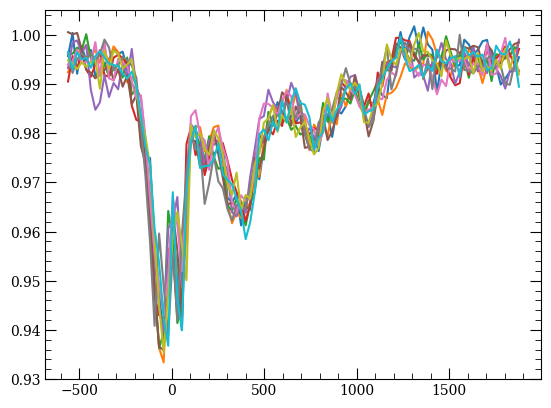

In [64]:
for file in files:
    x, y = load_data(file)
    x, y,_ = reduced_data(x,y)
    plt.plot(x,y)

In [10]:
from science import get_3491_RabiFreq_MHz, get_852_RabiFreq_MHz

In [11]:
get_852_RabiFreq_MHz(27.7)

np.float64(97.2581272515324)

In [36]:
get_3491_RabiFreq_MHz(0.05)

np.float64(7.067797937985062)

In [19]:
0.812/np.sqrt(0.365)

np.float64(1.3440319630902455)

In [18]:
2.2*1.3

2.8600000000000003

In [26]:
Pout = 0.47*1.3/0.6
print(Pout)

1.0183333333333333


In [30]:
Pout_max = 0.812*1.3/0.6
Pin_max = 2.1*1.3*0.6

In [31]:
Pmid_max = 0.5*(Pout_max + Pin_max)
print(Pmid_max)

1.698666666666667
